# 교과서에서 전처리·탐색한 `weather2023.xlsx`를 이용하여  
기온(temp), 풍속(wind), 습도(humi), 전운량(cloud)으로  
합계 일조시간(sunshine)을 예측하는 선형회귀 모델을 만드는 실습이다.

<탐구질문> 오늘의 기온, 풍속,습도, 전운량을 알면 일조시간을 예측할 수 있을까?

STEP 1. 라이브러리 불러오기와 데이터 확인


In [34]:
import pandas as pd
import matplotlib.pyplot as plt

weather = pd.read_excel('weather2023.xlsx', index_col = 'date')
weather.drop(['rain', 'location', 'loc_name'], axis = 1, inplace = True)
weather.head()

,temp,wind,humi,sunshine,cloud
date,,,,,
2023-01-01,-0.2,2.7,55.0,9.0,1.3
2023-01-02,-4.5,2.5,46.0,9.1,0.0
2023-01-03,-5.0,1.8,49.0,9.1,0.0
2023-01-04,-1.8,1.9,51.0,8.7,1.9
2023-01-05,-1.6,1.6,58.1,4.7,3.6


STEP2. 입력 데이터 X와 정답 y 정하기

In [72]:
X = weather[['temp', 'wind', 'humi', 'cloud']]
y = weather['sunshine']
print(X.head())
print(y.head())

            temp  wind  humi  cloud
date                               
2023-01-01  -0.2   2.7  55.0    1.3
2023-01-02  -4.5   2.5  46.0    0.0
2023-01-03  -5.0   1.8  49.0    0.0
2023-01-04  -1.8   1.9  51.0    1.9
2023-01-05  -1.6   1.6  58.1    3.6
date
2023-01-01    9.0
2023-01-02    9.1
2023-01-03    9.1
2023-01-04    8.7
2023-01-05    4.7
Name: sunshine, dtype: float64


STEP3. 훈련데이터와 테스트테이터로 분리하기

In [36]:
%pip install scikit-learn


Defaulting to user installation because normal site-packages is not writeable
You should consider upgrading via the '/Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [37]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)
print("훈련 데이터:" , X_train.shape)
print("테스트 데이터:" , X_test.shape)

훈련 데이터: (144, 4)
테스트 데이터: (37, 4)


STEP4. 선형회귀 모델 학습하기

In [74]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

STEP5. 테스트 데이터 예측하기

In [57]:
pred = model.predict(X_test)
result = pd.DataFrame({
    'original_index': y_test.index,
    'actual': y_test.values,
    'predicted': pred,
})

print(result.head(10))

  original_index  actual  predicted
0     2023-01-20     8.7  10.220608
1     2023-02-12     2.0   2.696020
2     2023-06-03    13.3  10.724790
3     2023-03-20    10.0   8.865658
4     2023-05-26    10.7   5.592091
5     2023-01-16     8.8   6.580402
6     2023-01-25     9.4   8.029100
7     2023-03-10     9.6  11.635115
8     2023-04-24     7.8   7.349061
9     2023-04-29     0.8   0.118703


STEP6. 모델 성능 평가하기

In [59]:
from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)
print('MAE:', mae)
print('R2:', r2)

MAE: 1.4872732719755142
R2: 0.773778772233753


STEP7. 실제값과 예측값 시각화하기


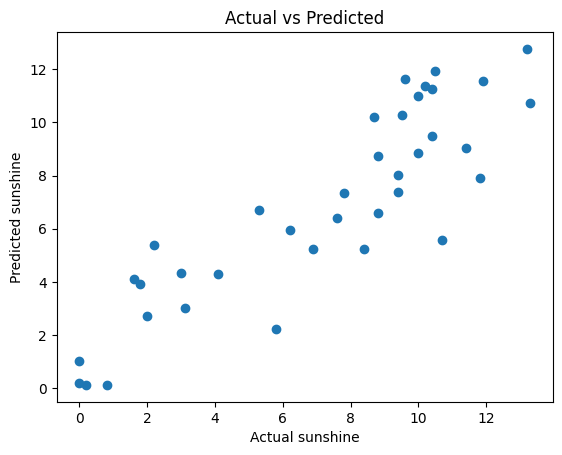

In [60]:
plt.scatter(y_test, pred)
plt.xlabel('Actual sunshine')
plt.ylabel('Predicted sunshine')
plt.title('Actual vs Predicted')
plt.show()

STEP 8. 새로운 날씨 데이터 예측하기
 - X값 중 하나 이상을 바꾸어 새로운 날씨의 일조 시간 예측

In [65]:
new_weather = pd.DataFrame(
    {
        'temp': [20.0],
        'wind': [2.5],
        'humi': [60.0],
        'cloud': [4.0],
    }
)
new_pred = model.predict(new_weather)
print('예측 일조시간: ', new_pred[0])

예측 일조시간:  8.467288641379062


STEP 9. 특성을 하나만 쓸 때와 여러개 쓸때 비교

In [75]:
X1 = weather[['cloud']]
y1 = weather['sunshine']
X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y, test_size = 0.2, random_state = 42
)

model1 = LinearRegression()
model1.fit(X1_train, y1_train)
pred1 = model1.predict(X1_test)

mae1 = mean_absolute_error(y1_test, pred1)
r21 = r2_score(y1_test, pred1)

print('cloud만 사용한 MAE:', mae1)
print('cloud만 사용한 R2:', r21)
print('4개 특성 사용 MAE:', mae)
print('4개 특성 사용 R2:', r2)

cloud만 사용한 MAE: 1.983557053359193
cloud만 사용한 R2: 0.6335007834575184
4개 특성 사용 MAE: 1.4872732719755142
4개 특성 사용 R2: 0.773778772233753


STEP10. 랜덤포레스트 회귀와 비교

<회귀 모델 성능지표 해석>
MAE: 작을수록 좋음 (실제값과 예측값이 평균적으로 얼마나 차이나는지?)
R2: 1에 가까울수록 좋음 (모델이 실제 데이터의 변화를 얼마나 잘 설명하는지?)